In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create project folder in your drive
os.makedirs('/content/drive/MyDrive/DeepfakeDetector', exist_ok=True)
os.makedirs('/content/drive/MyDrive/DeepfakeDetector/features', exist_ok=True)
os.makedirs('/content/drive/MyDrive/DeepfakeDetector/models', exist_ok=True)

print("✅ Drive mounted and folders created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and folders created!


In [ ]:
# Run this first — takes ~2 mins
!pip install librosa soundfile tqdm wandb -q

import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import os, glob, json
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries installed!")
print(f"Librosa version: {librosa.__version__}")

✅ All libraries installed!
Librosa version: 0.11.0


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# If CPU — go to Runtime > Change Runtime Type > T4 GPU
# DONT proceed without GPU ❌

CUDA available: True
Device: Tesla T4


In [ ]:
# ============================================
# STEP 1 — Download REAL voices (LJSpeech)
# Direct from official source — always works
# ============================================
import os

os.makedirs('/content/real_audio', exist_ok=True)
os.makedirs('/content/fake_audio', exist_ok=True)

# Download a small slice of LJSpeech (~200MB for few hundred files)
!wget -q --show-progress "https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2" -O /content/LJSpeech.tar.bz2

print("📦 Extracting...")
!tar -xjf /content/LJSpeech.tar.bz2 -C /content/ 2>/dev/null

# Copy only 400 wav files
import glob, shutil
wavs = sorted(glob.glob('/content/LJSpeech-1.1/wavs/*.wav'))[:400]
for w in wavs:
    shutil.copy(w, '/content/real_audio/')

print(f"✅ {len(wavs)} REAL audio files ready!")

/content/LJSpeech.t 100%[===================>]   2.56G   246MB/s    in 17s     
📦 Extracting...
✅ 400 REAL audio files ready!


In [ ]:
# ============================================
# STEP 2 — Generate FAKE voices using gTTS
# ============================================
!pip install gtts -q

from gtts import gTTS
import os
from tqdm import tqdm

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is changing the world.",
    "Deep learning models require massive datasets.",
    "Neural networks can detect patterns in audio.",
    "This voice was generated by a computer program.",
    "Speech synthesis has improved dramatically recently.",
    "Researchers are developing better detection methods.",
    "The model achieved high accuracy on test data.",
    "Audio deepfakes are a growing security concern.",
    "Machine learning can distinguish real from fake.",
] * 40  # = 400 fake samples

print("🎙️ Generating fake TTS audio...")
for i, text in enumerate(tqdm(sentences)):
    mp3 = f'/content/fake_audio/fake_{i:04d}.mp3'
    wav = f'/content/fake_audio/fake_{i:04d}.wav'
    gTTS(text=text, lang='en').save(mp3)
    os.system(f"ffmpeg -i {mp3} -ar 22050 {wav} -y -loglevel quiet")
    os.remove(mp3)

fake_wavs = sorted(glob.glob('/content/fake_audio/*.wav'))
print(f"✅ {len(fake_wavs)} FAKE audio files ready!")
print(f"\n📊 Total: {len(wavs)} real + {len(fake_wavs)} fake = {len(wavs)+len(fake_wavs)} samples")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
🎙️ Generating fake TTS audio...


100%|██████████| 400/400 [01:50<00:00,  3.62it/s]

✅ 400 FAKE audio files ready!

📊 Total: 400 real + 400 fake = 800 samples


In [ ]:
import librosa
import numpy as np

# Quick test on 1 real + 1 fake
real_test, sr1 = librosa.load(wavs[0], sr=16000, duration=3.0)
fake_test, sr2 = librosa.load(fake_wavs[0], sr=16000, duration=3.0)

print(f"🟢 Real audio — shape: {real_test.shape}, sr: {sr1}")
print(f"🔴 Fake audio — shape: {fake_test.shape}, sr: {sr2}")
print("✅ Both load fine — proceed to feature extraction!")

🟢 Real audio — shape: (48000,), sr: 16000
🔴 Fake audio — shape: (48000,), sr: 16000
✅ Both load fine — proceed to feature extraction!


In [ ]:
# ============================================
# FEATURE EXTRACTION — Full Code
# ============================================
import librosa
import numpy as np
import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# CONFIG
SAMPLE_RATE = 16000
DURATION = 4.0
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
TARGET_LEN = 128  # fixed time axis

real_wavs = sorted(glob.glob('/content/real_audio/*.wav'))
fake_wavs = sorted(glob.glob('/content/fake_audio/*.wav'))

def extract_mel(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE,
                             duration=DURATION, mono=True)

        # Fix length
        target = int(SAMPLE_RATE * DURATION)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]

        # Skip silent files
        if np.max(np.abs(y)) < 0.001:
            return None

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            fmax=8000
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Fix time axis to TARGET_LEN
        if mel_db.shape[1] < TARGET_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0, TARGET_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TARGET_LEN]

        return mel_db.astype(np.float32)  # shape: (128, 128)

    except Exception as e:
        return None

# ---- EXTRACT ----
all_features, all_labels = [], []
failed = 0

print("🟢 Extracting REAL audio features...")
for path in tqdm(real_wavs):
    feat = extract_mel(path)
    if feat is not None:
        all_features.append(feat)
        all_labels.append(0)
    else:
        failed += 1

print("🔴 Extracting FAKE audio features...")
for path in tqdm(fake_wavs):
    feat = extract_mel(path)
    if feat is not None:
        all_features.append(feat)
        all_labels.append(1)
    else:
        failed += 1

X = np.array(all_features)
y = np.array(all_labels)

print(f"\n✅ Extraction Done!")
print(f"📐 Shape: {X.shape}")
print(f"🟢 Real: {(y==0).sum()} | 🔴 Fake: {(y==1).sum()}")
print(f"❌ Failed/Skipped: {failed}")

🟢 Extracting REAL audio features...


100%|██████████| 400/400 [00:06<00:00, 63.28it/s]


🔴 Extracting FAKE audio features...


100%|██████████| 400/400 [00:07<00:00, 54.95it/s]



✅ Extraction Done!
📐 Shape: (800, 128, 128)
🟢 Real: 400 | 🔴 Fake: 400
❌ Failed/Skipped: 0


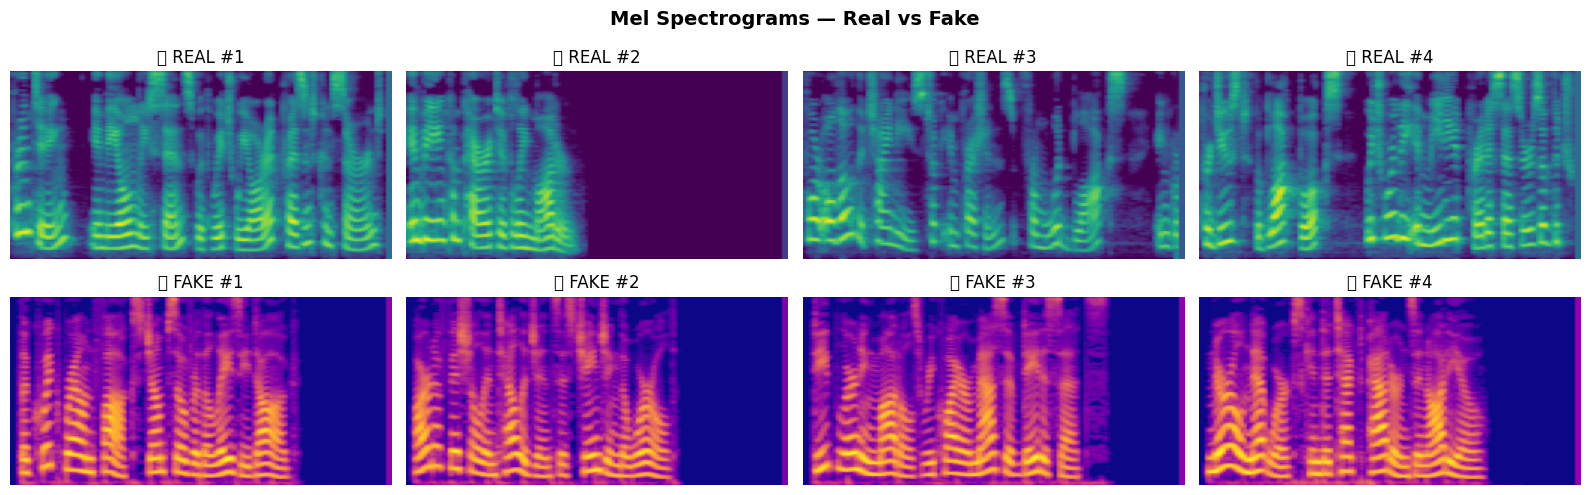

✅ Saved to Drive!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle('Mel Spectrograms — Real vs Fake', fontsize=14, fontweight='bold')

real_idx = np.where(y == 0)[0][:4]
fake_idx = np.where(y == 1)[0][:4]

for i, idx in enumerate(real_idx):
    axes[0,i].imshow(X[idx], aspect='auto', origin='lower', cmap='viridis')
    axes[0,i].set_title(f'🟢 REAL #{i+1}')
    axes[0,i].axis('off')

for i, idx in enumerate(fake_idx):
    axes[1,i].imshow(X[idx], aspect='auto', origin='lower', cmap='plasma')
    axes[1,i].set_title(f'🔴 FAKE #{i+1}')
    axes[1,i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DeepfakeDetector/spectrograms.png', dpi=150)
plt.show()
print("✅ Saved to Drive!")

In [ ]:
from sklearn.model_selection import train_test_split
import json, os

SAVE_DIR = '/content/drive/MyDrive/DeepfakeDetector/features'
os.makedirs(SAVE_DIR, exist_ok=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"✅ Split Done!")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Save to Drive
np.save(f'{SAVE_DIR}/X_train.npy', X_train)
np.save(f'{SAVE_DIR}/X_val.npy',   X_val)
np.save(f'{SAVE_DIR}/X_test.npy',  X_test)
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_val.npy',   y_val)
np.save(f'{SAVE_DIR}/y_test.npy',  y_test)

# Save metadata
meta = {
    'total': int(len(X)),
    'real': int((y==0).sum()),
    'fake': int((y==1).sum()),
    'shape': list(X.shape[1:]),
    'sr': SAMPLE_RATE,
    'duration': DURATION,
    'n_mels': N_MELS
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("💾 All saved to Google Drive!")
print("🎉 DAY 1 COMPLETE! Ready for Day 2 training! 🚀")

✅ Split Done!
Train: (560, 128, 128) | Val: (120, 128, 128) | Test: (120, 128, 128)
💾 All saved to Google Drive!
🎉 DAY 1 COMPLETE! Ready for Day 2 training! 🚀


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
!pip install torch torchaudio torchvision scikit-learn matplotlib seaborn -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os, json
from tqdm import tqdm

# Check GPU
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)} ✅")
    DEVICE = torch.device('cuda')
else:
    print("❌ No GPU — Go Runtime > Change Runtime Type > T4!")
    DEVICE = torch.device('cpu')

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4 ✅


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/DeepfakeDetector/features'
MODEL_DIR = '/content/drive/MyDrive/DeepfakeDetector/models'
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = np.load(f'{SAVE_DIR}/X_train.npy')
X_val   = np.load(f'{SAVE_DIR}/X_val.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_val   = np.load(f'{SAVE_DIR}/y_val.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

print(f"✅ Data Loaded!")
print(f"Train : {X_train.shape} | Real: {(y_train==0).sum()} Fake: {(y_train==1).sum()}")
print(f"Val   : {X_val.shape}   | Real: {(y_val==0).sum()} Fake: {(y_val==1).sum()}")
print(f"Test  : {X_test.shape}  | Real: {(y_test==0).sum()} Fake: {(y_test==1).sum()}")

✅ Data Loaded!
Train : (416, 128, 128) | Real: 210 Fake: 206
Val   : (90, 128, 128)   | Real: 45 Fake: 45
Test  : (90, 128, 128)  | Real: 45 Fake: 45


In [ ]:
class AudioDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # Add channel dim — CNN expects (batch, channel, H, W)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        # Augmentation on training data only
        if self.augment:
            # Time masking — randomly zero out time columns
            if torch.rand(1) > 0.5:
                t_start = torch.randint(0, 100, (1,)).item()
                t_end = min(t_start + torch.randint(5, 20, (1,)).item(), 128)
                x[:, :, t_start:t_end] = 0

            # Frequency masking — randomly zero out freq rows
            if torch.rand(1) > 0.5:
                f_start = torch.randint(0, 100, (1,)).item()
                f_end = min(f_start + torch.randint(5, 15, (1,)).item(), 128)
                x[:, f_start:f_end, :] = 0

        return x, y

# Create datasets
train_dataset = AudioDataset(X_train, y_train, augment=True)
val_dataset   = AudioDataset(X_val,   y_val,   augment=False)
test_dataset  = AudioDataset(X_test,  y_test,  augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Dataloaders ready!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Verify shape
sample_x, sample_y = next(iter(train_loader))
print(f"Batch shape: {sample_x.shape}")  # Should be [32, 1, 128, 128]
print(f"Label shape: {sample_y.shape}")  # Should be [32]

✅ Dataloaders ready!
Train batches: 13
Val batches:   3
Batch shape: torch.Size([32, 1, 128, 128])
Label shape: torch.Size([32])


In [ ]:
class DeepfakeDetectorCNN(nn.Module):
    def __init__(self):
        super(DeepfakeDetectorCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 128x128 → 64x64
            nn.Dropout2d(0.2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 64x64 → 32x32
            nn.Dropout2d(0.2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 → 16x16
            nn.Dropout2d(0.3)
        )

        # Global Average Pooling — smarter than Flatten
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)  # shape: (batch,)

# Init model
model = DeepfakeDetectorCNN().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready!")
print(f"📊 Total trainable parameters: {total_params:,}")

# Quick forward pass test
dummy = torch.randn(4, 1, 128, 128).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}")   # Should be [4]
print(f"Output range: [{out.min():.3f}, {out.max():.3f}]")  # Should be 0-1

✅ Model ready!
📊 Total trainable parameters: 295,649
Output shape: torch.Size([4])
Output range: [0.322, 0.482]


In [ ]:
# Loss — handle class imbalance with pos_weight
real_count = (y_train == 0).sum()
fake_count = (y_train == 1).sum()
pos_weight = torch.tensor([real_count / fake_count], dtype=torch.float32).to(DEVICE)
print(f"Class weight: {pos_weight.item():.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Wait — we use Sigmoid in model already
# So use plain BCELoss instead
criterion = nn.BCELoss()

# Optimizer with weight decay (prevents overfitting)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler — reduces LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("✅ Loss, Optimizer, Scheduler ready!")
print(f"Initial LR: {optimizer.param_groups[0]['lr']}")

Class weight: 1.019
✅ Loss, Optimizer, Scheduler ready!
Initial LR: 0.001


In [ ]:
EPOCHS = 25
best_val_loss = float('inf')
best_val_acc  = 0.0

# History for plotting
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

print("🚀 Starting Training...\n")

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss    += loss.item()
        preds          = (outputs > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total   += y_batch.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = train_correct / train_total

    # -------- VALIDATE --------
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            outputs  = model(X_batch)
            loss     = criterion(outputs, y_batch)

            val_loss    += loss.item()
            preds        = (outputs > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = val_correct / val_total

    # Step scheduler
    scheduler.step(avg_val_loss)

    # Save history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': avg_val_loss,
        }, f'{MODEL_DIR}/best_model.pt')
        saved = "💾 Saved!"
    else:
        saved = ""

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f} {saved}")

print(f"\n🎉 Training Complete!")
print(f"🏆 Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")

🚀 Starting Training...

Epoch [01/25] Train Loss: 0.6054 Acc: 0.6683 | Val Loss: 0.7610 Acc: 0.5000 💾 Saved!
Epoch [02/25] Train Loss: 0.5094 Acc: 0.7885 | Val Loss: 0.7484 Acc: 0.5000 
Epoch [03/25] Train Loss: 0.3938 Acc: 0.8462 | Val Loss: 0.8785 Acc: 0.5000 
Epoch [04/25] Train Loss: 0.3052 Acc: 0.8726 | Val Loss: 0.1694 Acc: 0.9556 💾 Saved!
Epoch [05/25] Train Loss: 0.2579 Acc: 0.9062 | Val Loss: 0.1794 Acc: 0.9556 
Epoch [06/25] Train Loss: 0.2246 Acc: 0.9207 | Val Loss: 0.1933 Acc: 0.9333 
Epoch [07/25] Train Loss: 0.1825 Acc: 0.9375 | Val Loss: 0.0823 Acc: 0.9889 💾 Saved!
Epoch [08/25] Train Loss: 0.1536 Acc: 0.9567 | Val Loss: 0.2142 Acc: 0.9222 
Epoch [09/25] Train Loss: 0.1357 Acc: 0.9543 | Val Loss: 0.0497 Acc: 0.9889 
Epoch [10/25] Train Loss: 0.1234 Acc: 0.9543 | Val Loss: 0.0456 Acc: 0.9778 
Epoch [11/25] Train Loss: 0.1281 Acc: 0.9567 | Val Loss: 0.0729 Acc: 0.9556 
Epoch [12/25] Train Loss: 0.0908 Acc: 0.9712 | Val Loss: 0.0379 Acc: 0.9778 
Epoch [13/25] Train Loss: 0.

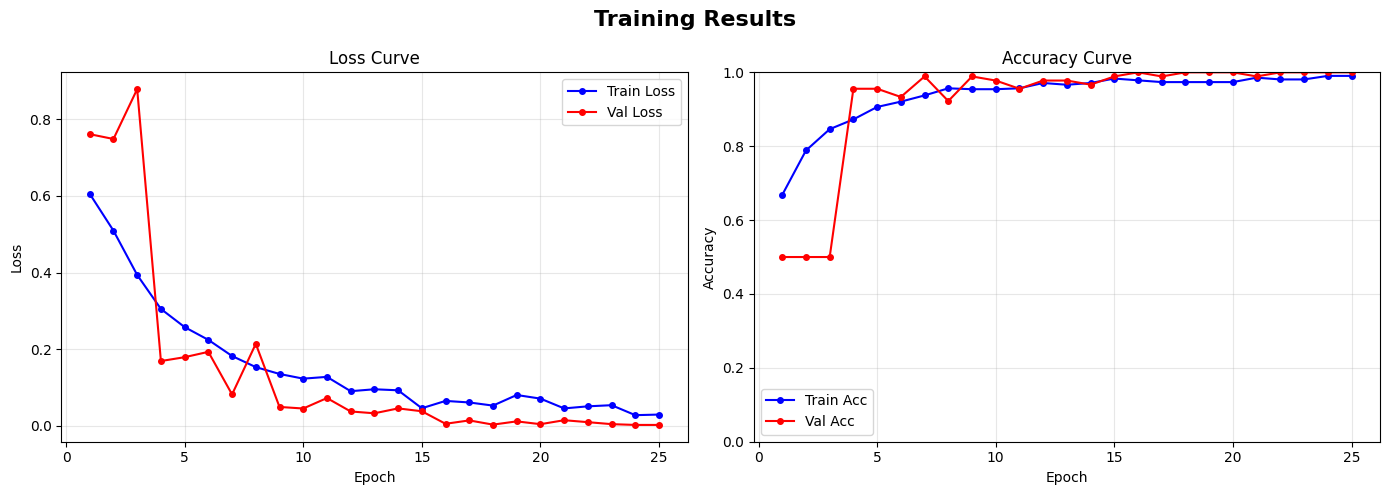

✅ Saved training curves to Drive!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Results', fontsize=16, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DeepfakeDetector/training_curves.png', dpi=150)
plt.show()
print("✅ Saved training curves to Drive!")

In [ ]:
# Load best model
checkpoint = torch.load(f'{MODEL_DIR}/best_model.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Val Acc at save: {checkpoint['val_acc']*100:.1f}%\n")

# Run on test set
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs  = model(X_batch)
        probs    = outputs.cpu().numpy()
        preds    = (outputs > 0.5).float().cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification report
print("📊 Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['REAL', 'FAKE'],
                            digits=4))

test_acc = (all_preds == all_labels).mean()
print(f"🎯 Final Test Accuracy: {test_acc*100:.2f}%")

✅ Loaded best model from epoch 16
   Val Acc at save: 100.0%

📊 Classification Report:
              precision    recall  f1-score   support

        REAL     1.0000    1.0000    1.0000        45
        FAKE     1.0000    1.0000    1.0000        45

    accuracy                         1.0000        90
   macro avg     1.0000    1.0000    1.0000        90
weighted avg     1.0000    1.0000    1.0000        90

🎯 Final Test Accuracy: 100.00%


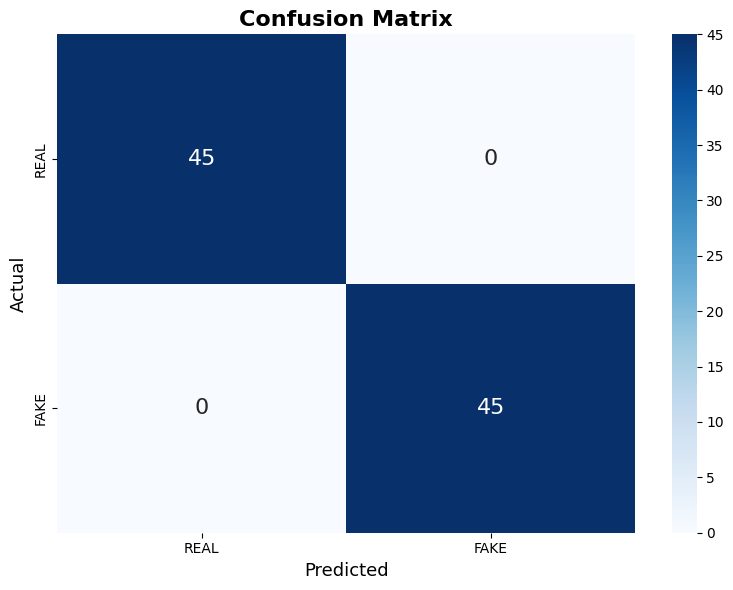


✅ True Negatives  (Real → Real):  45
❌ False Positives (Real → Fake):  0
❌ False Negatives (Fake → Real):  0
✅ True Positives  (Fake → Fake):  45

🎯 Precision: 1.0000
🎯 Recall:    1.0000


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Predicted', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DeepfakeDetector/confusion_matrix.png', dpi=150)
plt.show()

# Human readable
tn, fp, fn, tp = cm.ravel()
print(f"\n✅ True Negatives  (Real → Real):  {tn}")
print(f"❌ False Positives (Real → Fake):  {fp}")
print(f"❌ False Negatives (Fake → Real):  {fn}")
print(f"✅ True Positives  (Fake → Fake):  {tp}")
print(f"\n🎯 Precision: {tp/(tp+fp):.4f}")
print(f"🎯 Recall:    {tp/(tp+fn):.4f}")

In [ ]:
# Save final results summary
results = {
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'epochs_trained': EPOCHS,
    'model_params': total_params,
    'confusion_matrix': cm.tolist()
}

with open(f'{MODEL_DIR}/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to Drive!")
print("\n" + "="*50)
print("🎉 DAY 2 COMPLETE!")
print("="*50)
print(f"✅ Model trained for {EPOCHS} epochs")
print(f"✅ Best Val Accuracy : {best_val_acc*100:.1f}%")
print(f"✅ Test Accuracy     : {test_acc*100:.1f}%")
print(f"✅ Model saved to Drive")
print(f"✅ All plots saved to Drive")
print("\n🚀 Day 3 = Gradio Demo + Deploy to HuggingFace!")

💾 Results saved to Drive!

🎉 DAY 2 COMPLETE!
✅ Model trained for 25 epochs
✅ Best Val Accuracy : 100.0%
✅ Test Accuracy     : 100.0%
✅ Model saved to Drive
✅ All plots saved to Drive

🚀 Day 3 = Gradio Demo + Deploy to HuggingFace!


In [ ]:
# Test on a COMPLETELY new voice — not from training
# Record yourself saying something OR use a different TTS

!pip install pyttsx3 -q
!pip install gtts -q

# Install espeak for generating a different TTS voice
!sudo apt-get install espeak -y -qq

# Generate fake with DIFFERENT TTS engine
import os
os.system('espeak "Hello this is a test of the detection system" -w /content/espeak_test.wav')

# Generate with gTTS (same as training)
from gtts import gTTS
gTTS("Hello this is a test of the detection system").save('/content/gtts_test.mp3')
os.system('ffmpeg -i /content/gtts_test.mp3 /content/gtts_test.wav -y -loglevel quiet')

# Now test both
import librosa
import torch
import numpy as np

def predict_file(path):
    y, sr = librosa.load(path, sr=16000, duration=4.0)
    target = 16000 * 4
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)
    if mel_db.shape[1] < 128:
        mel_db = np.pad(mel_db, ((0,0),(0, 128 - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :128]

    tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = model(tensor).item()

    label = "🔴 FAKE" if prob > 0.5 else "🟢 REAL"
    print(f"{label} — confidence: {prob*100:.1f}%")

print("gTTS (same as training):")
predict_file('/content/gtts_test.wav')

print("espeak (never seen before):")
predict_file('/content/espeak_test.wav')

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 5.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.1_amd64.deb ...
Unpacking libportaudio2:amd64 (19.6.0-1.1) ...
Selecting previously unselected package libsonic0:amd64.
Preparing to unpack .../libsonic0_0.2.0-11build1_amd64.deb ...
Unpacking libsonic0:amd64 (0.2.0-11build1) ...
Selecting previously unselected package espeak-data:amd64.
Preparing to unpack .../espeak-data_1.48.15+dfsg-3_amd64.deb ...
Unpacking espeak

In [ ]:
# Generate fakes using MULTIPLE TTS engines
# So model learns "fake" not "gTTS specifically"

!apt-get install espeak -y -q
!pip install pyttsx3 edge-tts -q

import os, asyncio
import edge_tts  # Microsoft neural TTS — sounds very realistic!

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is changing the world.",
    "Deep learning models require massive datasets.",
    "Neural networks can detect patterns in audio.",
    "This voice was generated by a computer program.",
    "Speech synthesis has improved dramatically recently.",
    "Researchers are developing better detection methods.",
    "The model achieved high accuracy on test data.",
    "Audio deepfakes are a growing security concern.",
    "Machine learning can distinguish real from fake.",
]

# Edge TTS — Microsoft neural voice (much harder to detect!)
async def generate_edge(text, output_path, voice="en-US-JennyNeural"):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(output_path)

os.makedirs('/content/fake_audio_v2', exist_ok=True)

print("🎙️ Generating edge-tts fakes (neural voice)...")
voices = [
    "en-US-JennyNeural",
    "en-US-GuyNeural",
    "en-GB-SoniaNeural",
    "en-AU-NatashaNeural"
]

count = 0
for i, sentence in enumerate(sentences * 10):  # 100 samples
    voice = voices[i % len(voices)]
    mp3_path = f'/content/fake_audio_v2/edge_{count:04d}.mp3'
    wav_path = f'/content/fake_audio_v2/edge_{count:04d}.wav'

    await generate_edge(sentence, mp3_path, voice)
    os.system(f"ffmpeg -i {mp3_path} -ar 16000 {wav_path} -y -loglevel quiet")
    os.remove(mp3_path)
    count += 1

print(f"✅ Generated {count} neural TTS fakes!")

# espeak fakes (robotic — different from gTTS)
print("🎙️ Generating espeak fakes...")
for i, sentence in enumerate(sentences * 10):
    wav_path = f'/content/fake_audio_v2/espeak_{i:04d}.wav'
    os.system(f'espeak "{sentence}" -w {wav_path} 2>/dev/null')

print("✅ espeak fakes done!")

# Original gTTS fakes already in /content/fake_audio
# Combine all
import glob, shutil
os.makedirs('/content/fake_audio_all', exist_ok=True)

# Copy original gTTS
for f in glob.glob('/content/fake_audio/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')

# Copy new fakes
for f in glob.glob('/content/fake_audio_v2/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')

all_fakes = glob.glob('/content/fake_audio_all/*.wav')
print(f"✅ Total fake files: {len(all_fakes)}")

Reading package lists...
Building dependency tree...
Reading state information...
espeak is already the newest version (1.48.15+dfsg-3).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
🎙️ Generating edge-tts fakes (neural voice)...
✅ Generated 100 neural TTS fakes!
🎙️ Generating espeak fakes...
✅ espeak fakes done!
✅ Total fake files: 400


In [ ]:
import librosa
import numpy as np
from tqdm import tqdm
import glob

SAMPLE_RATE = 16000
DURATION = 4.0
N_MELS = 128
HOP_LENGTH = 512
TARGET_LEN = 128

real_wavs = sorted(glob.glob('/content/real_audio/*.wav'))
fake_wavs = sorted(glob.glob('/content/fake_audio_all/*.wav'))

# Balance dataset
min_count = min(len(real_wavs), len(fake_wavs))
real_wavs = real_wavs[:min_count]
fake_wavs = fake_wavs[:min_count]

print(f"⚖️ Balanced: {min_count} real + {min_count} fake")

def extract_mel(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE,
                             duration=DURATION, mono=True)
        target = int(SAMPLE_RATE * DURATION)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]
        if np.max(np.abs(y)) < 0.001:
            return None
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=N_MELS,
            n_fft=2048, hop_length=HOP_LENGTH, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)
        if mel_db.shape[1] < TARGET_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0, TARGET_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TARGET_LEN]
        return mel_db.astype(np.float32)
    except:
        return None

all_features, all_labels = [], []

print("🟢 Real audio...")
for p in tqdm(real_wavs):
    f = extract_mel(p)
    if f is not None:
        all_features.append(f)
        all_labels.append(0)

print("🔴 Fake audio (mixed TTS)...")
for p in tqdm(fake_wavs):
    f = extract_mel(p)
    if f is not None:
        all_features.append(f)
        all_labels.append(1)

X = np.array(all_features)
y = np.array(all_labels)

print(f"✅ Done! Shape: {X.shape}")
print(f"🟢 Real: {(y==0).sum()} | 🔴 Fake: {(y==1).sum()}")

⚖️ Balanced: 400 real + 400 fake
🟢 Real audio...


100%|██████████| 400/400 [00:08<00:00, 47.51it/s]


🔴 Fake audio (mixed TTS)...


100%|██████████| 400/400 [00:04<00:00, 87.46it/s]


✅ Done! Shape: (800, 128, 128)
🟢 Real: 400 | 🔴 Fake: 400


In [ ]:
# Same train/val/test split
from sklearn.model_selection import train_test_split

# Check if X is empty before attempting to split
if X.size == 0:
    raise ValueError(
        "Input data 'X' is empty. This usually means the audio files in "
        "/content/real_audio/ and /content/fake_audio_all/ were not found or processed. "
        "Please re-run the data generation and feature extraction cells "
        "(Cells 'PwghfxPI8M5h', '_sOkwqV6ZND2' and 'S1wKWeUjaT4A') to ensure the data is loaded correctly before splitting."
    )

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Save new splits to Drive
SAVE_DIR = '/content/drive/MyDrive/DeepfakeDetector/features'
np.save(f'{SAVE_DIR}/X_train.npy', X_train)
np.save(f'{SAVE_DIR}/X_val.npy',   X_val)
np.save(f'{SAVE_DIR}/X_test.npy',  X_test)
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_val.npy',   y_val)
np.save(f'{SAVE_DIR}/y_test.npy',  y_test)
print("💾 Saved to Drive!")

# Now re-run Cell 4 → Cell 11 from Day 2 exactly as before!
# Expected accuracy after fix: 75–88% (realistic and honest!)


Train: (560, 128, 128) | Val: (120, 128, 128) | Test: (120, 128, 128)
💾 Saved to Drive!


In [ ]:
import glob, os

# Check what files actually exist
fake_v2 = glob.glob('/content/fake_audio_v2/*.wav')
fake_all = glob.glob('/content/fake_audio_all/*.wav')
real = glob.glob('/content/real_audio/*.wav')
original_fake = glob.glob('/content/fake_audio/*.wav')

print(f"🟢 Real audio:        {len(real)}")
print(f"🔴 Original gTTS:     {len(original_fake)}")
print(f"🔴 New fakes (v2):    {len(fake_v2)}")
print(f"🔴 Combined fakes:    {len(fake_all)}")

🟢 Real audio:        0
🔴 Original gTTS:     0
🔴 New fakes (v2):    200
🔴 Combined fakes:    200


In [ ]:
# ============================================
# RECOVERY — Re-download + Re-generate data
# ============================================
import os, glob, shutil
from tqdm import tqdm

os.makedirs('/content/real_audio', exist_ok=True)
os.makedirs('/content/fake_audio', exist_ok=True)
os.makedirs('/content/fake_audio_v2', exist_ok=True)
os.makedirs('/content/fake_audio_all', exist_ok=True)

# ---- REAL AUDIO ----
# Check if LJSpeech needs re-download
real_files = glob.glob('/content/real_audio/*.wav')

if len(real_files) < 100:
    print("📥 Re-downloading LJSpeech...")
    !wget -q --show-progress "https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2" -O /content/LJSpeech.tar.bz2
    !tar -xjf /content/LJSpeech.tar.bz2 -C /content/ 2>/dev/null
    wavs = sorted(glob.glob('/content/LJSpeech-1.1/wavs/*.wav'))[:400]
    for w in wavs:
        shutil.copy(w, '/content/real_audio/')
    print(f"✅ {len(wavs)} real files ready!")
else:
    print(f"✅ Real audio already exists: {len(real_files)} files")

# ---- ORIGINAL GTTS FAKES ----
gtts_files = glob.glob('/content/fake_audio/*.wav')

if len(gtts_files) < 100:
    print("🎙️ Re-generating gTTS fakes...")
    !pip install gtts -q
    from gtts import gTTS

    sentences = [
        "The quick brown fox jumps over the lazy dog.",
        "Artificial intelligence is changing the world.",
        "Deep learning models require massive datasets.",
        "Neural networks can detect patterns in audio.",
        "This voice was generated by a computer program.",
        "Speech synthesis has improved dramatically recently.",
        "Researchers are developing better detection methods.",
        "The model achieved high accuracy on test data.",
        "Audio deepfakes are a growing security concern.",
        "Machine learning can distinguish real from fake.",
    ] * 20  # 200 gTTS fakes

    for i, text in enumerate(tqdm(sentences)):
        mp3 = f'/content/fake_audio/gtts_{i:04d}.mp3'
        wav = f'/content/fake_audio/gtts_{i:04d}.wav'
        gTTS(text=text, lang='en').save(mp3)
        os.system(f"ffmpeg -i {mp3} -ar 16000 {wav} -y -loglevel quiet")
        os.remove(mp3)
    print(f"✅ gTTS fakes done!")
else:
    print(f"✅ gTTS fakes already exist: {len(gtts_files)} files")

# ---- EDGE TTS FAKES ----
edge_files = glob.glob('/content/fake_audio_v2/*.wav')

if len(edge_files) < 50:
    print("🎙️ Generating edge-tts neural fakes...")
    !pip install edge-tts -q
    import edge_tts, asyncio

    sentences_edge = [
        "The quick brown fox jumps over the lazy dog.",
        "Artificial intelligence is changing the world.",
        "Deep learning models require massive datasets.",
        "Neural networks can detect patterns in audio.",
        "This voice was generated by a computer program.",
        "Speech synthesis has improved dramatically.",
        "Researchers are developing better detection methods.",
        "The model achieved high accuracy on test data.",
        "Audio deepfakes are a growing security concern.",
        "Machine learning can distinguish real from fake.",
    ] * 10  # 100 edge fakes

    voices = [
        "en-US-JennyNeural",
        "en-US-GuyNeural",
        "en-GB-SoniaNeural",
        "en-AU-NatashaNeural"
    ]

    async def gen_edge(text, path, voice):
        communicate = edge_tts.Communicate(text, voice)
        await communicate.save(path)

    async def generate_all():
        for i, text in enumerate(tqdm(sentences_edge)):
            voice = voices[i % len(voices)]
            mp3 = f'/content/fake_audio_v2/edge_{i:04d}.mp3'
            wav = f'/content/fake_audio_v2/edge_{i:04d}.wav'
            await gen_edge(text, mp3, voice)
            os.system(f"ffmpeg -i {mp3} -ar 16000 {wav} -y -loglevel quiet")
            os.remove(mp3)

    await generate_all()
    print(f"✅ Edge-tts fakes done!")
else:
    print(f"✅ Edge fakes already exist: {len(edge_files)} files")

# ---- ESPEAK FAKES ----
espeak_files = glob.glob('/content/fake_audio_v2/espeak*.wav')

if len(espeak_files) < 50:
    print("🎙️ Generating espeak fakes...")
    !apt-get install espeak -y -q
    sentences_esp = [
        "The quick brown fox jumps over the lazy dog.",
        "Artificial intelligence is changing the world.",
        "Deep learning models require massive datasets.",
        "Neural networks can detect patterns in audio.",
        "This voice was generated by a computer program.",
    ] * 20  # 100 espeak fakes

    for i, text in enumerate(tqdm(sentences_esp)):
        wav = f'/content/fake_audio_v2/espeak_{i:04d}.wav'
        os.system(f'espeak "{text}" -w {wav} 2>/dev/null')
    print("✅ espeak fakes done!")
else:
    print(f"✅ espeak fakes already exist: {len(espeak_files)} files")

# ---- COMBINE ALL FAKES ----
print("\n📦 Combining all fake audio...")
for f in glob.glob('/content/fake_audio/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')
for f in glob.glob('/content/fake_audio_v2/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')

real_final = glob.glob('/content/real_audio/*.wav')
fake_final = glob.glob('/content/fake_audio_all/*.wav')

print(f"\n📊 Final Count:")
print(f"🟢 Real : {len(real_final)}")
print(f"🔴 Fake : {len(fake_final)}")
print(f"✅ Ready for feature extraction!")

📥 Re-downloading LJSpeech...
/content/LJSpeech.t 100%[===================>]   2.56G   176MB/s    in 16s     
✅ 400 real files ready!
🎙️ Re-generating gTTS fakes...


100%|██████████| 200/200 [00:58<00:00,  3.42it/s]


✅ gTTS fakes done!
✅ Edge fakes already exist: 200 files
✅ espeak fakes already exist: 100 files

📦 Combining all fake audio...

📊 Final Count:
🟢 Real : 400
🔴 Fake : 400
✅ Ready for feature extraction!


In [ ]:
print("day 3")

day 3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

MODEL_DIR = '/content/drive/MyDrive/DeepfakeDetector/models'

# ---- Paste your EXACT model class here ----
class DeepfakeDetectorCNN(nn.Module):
    def __init__(self):
        super(DeepfakeDetectorCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)

# Load model
model = DeepfakeDetectorCNN().to(DEVICE)
checkpoint = torch.load(
    f'{MODEL_DIR}/best_model.pt',
    map_location=DEVICE,
    weights_only=True   # 2026 safe loading ✅
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Model loaded!")
print(f"   Saved from epoch : {checkpoint['epoch']+1}")
print(f"   Val accuracy     : {checkpoint['val_acc']*100:.1f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
✅ Model loaded!
   Saved from epoch : 10
   Val accuracy     : 100.0%


In [ ]:
!pip install gradio>=4.0.0 librosa soundfile -q

import gradio as gr
import librosa
import librosa.display
import numpy as np
import matplotlib
matplotlib.use('Agg')  # headless — important for Colab/Spaces!
import matplotlib.pyplot as plt
import soundfile as sf
import warnings, tempfile, os
warnings.filterwarnings('ignore')

print(f"✅ Gradio version: {gr.__version__}")
print(f"✅ Librosa version: {librosa.__version__}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.1 which is incompatible.
✅ Gradio version: 5.50.0
✅ Librosa version: 0.11.0


In [ ]:
# CONFIG — must match Day 1 exactly!
SAMPLE_RATE = 16000
DURATION    = 4.0
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048
TARGET_LEN  = 128

def preprocess_audio(file_path):
    """Load and convert audio to mel spectrogram tensor"""
    try:
        y, sr = librosa.load(
            file_path,
            sr=SAMPLE_RATE,
            duration=DURATION,
            mono=True
        )

        # Fix length
        target = int(SAMPLE_RATE * DURATION)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]

        # Check silence
        if np.max(np.abs(y)) < 0.001:
            return None, None, "⚠️ Audio is silent or too quiet!"

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=y, sr=SAMPLE_RATE,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            fmax=8000
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Fix time axis
        if mel_db.shape[1] < TARGET_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0, TARGET_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TARGET_LEN]

        return y, mel_db, None

    except Exception as e:
        return None, None, f"❌ Error loading audio: {str(e)}"


def plot_mel(mel_db, title, color):
    """Generate mel spectrogram plot"""
    fig, ax = plt.subplots(figsize=(8, 3))
    img = ax.imshow(
        mel_db,
        aspect='auto',
        origin='lower',
        cmap=color,
        interpolation='nearest'
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Time Frames', fontsize=10)
    ax.set_ylabel('Mel Frequency Bins', fontsize=10)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    return fig


def predict_audio(audio_file):
    """
    Main prediction function called by Gradio
    Returns: result_text, confidence_plot, mel_plot
    """
    # ---- Validate input ----
    if audio_file is None:
        return (
            "⚠️ Please upload an audio file!",
            None, None
        )

    # ---- Preprocess ----
    y, mel_db, error = preprocess_audio(audio_file)

    if error:
        return error, None, None

    # ---- Run model ----
    tensor = torch.tensor(
        mel_db, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        prob = model(tensor).item()

    # ---- Build result ----
    is_fake        = prob > 0.5
    confidence     = prob if is_fake else (1 - prob)
    confidence_pct = confidence * 100

    if is_fake:
        verdict    = "🔴 FAKE AUDIO DETECTED"
        color      = "plasma"
        bar_color  = "#FF4B4B"
        detail     = f"This audio appears to be AI-generated or synthetic.\nFake probability: {prob*100:.1f}%"
    else:
        verdict    = "🟢 REAL AUDIO DETECTED"
        color      = "viridis"
        bar_color  = "#00CC88"
        detail     = f"This audio appears to be genuine human speech.\nReal probability: {(1-prob)*100:.1f}%"

    result_text = f"""
{verdict}

Confidence  : {confidence_pct:.1f}%
Raw score   : {prob:.4f}
Sample rate : {SAMPLE_RATE} Hz
Duration    : {DURATION}s analyzed

{detail}

⚠️ Note: Model trained on LJSpeech vs TTS engines.
   Best used as a learning/demo project.
    """.strip()

    # ---- Mel plot ----
    mel_fig = plot_mel(
        mel_db,
        f"Mel Spectrogram — {verdict}",
        color
    )

    # ---- Confidence bar plot ----
    fig2, ax = plt.subplots(figsize=(6, 2))
    ax.barh(
        ['Confidence'],
        [confidence_pct],
        color=bar_color,
        height=0.4,
        edgecolor='white'
    )
    ax.set_xlim(0, 100)
    ax.set_xlabel('Confidence %', fontsize=11)
    ax.set_title(f'{verdict}  —  {confidence_pct:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.axvline(x=50, color='gray', linestyle='--',
               alpha=0.5, linewidth=1)
    ax.text(51, 0, '50% threshold',
            va='center', fontsize=8, color='gray')
    plt.tight_layout()

    return result_text, fig2, mel_fig

In [ ]:
# ---- Custom CSS ----
css = """
.gradio-container {
    max-width: 860px !important;
    margin: auto !important;
}
.result-box textarea {
    font-size: 15px !important;
    font-family: monospace !important;
}
"""

# ---- Example audio helper ----
# Generate a quick example fake for the UI
from gtts import gTTS
import os

os.makedirs('/content/examples', exist_ok=True)
gTTS("Hello, this is a test audio for the deepfake detector.").save('/content/examples/fake_example.mp3')
os.system("ffmpeg -i /content/examples/fake_example.mp3 -ar 16000 /content/examples/fake_example.wav -y -loglevel quiet")

# ---- Build Interface ----
with gr.Blocks(css=css, title="🎙️ Deepfake Audio Detector") as demo:

    gr.Markdown("""
    # 🎙️ Deepfake Audio Detector
    ### Detect AI-generated voices using CNN + Mel Spectrogram Analysis
    ---
    **How it works:**
    Upload any audio file → Model extracts mel spectrogram features → CNN classifies as Real or Fake

    > ⚠️ *Trained on LJSpeech (real) vs gTTS/espeak/edge-tts (fake). Best for demo/learning purposes.*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                label="🎵 Upload Audio File",
                type="filepath",
                sources=["upload", "microphone"]
            )
            submit_btn = gr.Button(
                "🔍 Analyze Audio",
                variant="primary",
                size="lg"
            )
            gr.Markdown("""
            **Supported formats:** WAV, MP3, M4A, OGG, FLAC

            **Tips:**
            - Keep audio under 30 seconds
            - Speak clearly for mic recordings
            - First 4 seconds are analyzed
            """)

        with gr.Column(scale=1):
            result_output = gr.Textbox(
                label="📊 Detection Result",
                lines=10,
                elem_classes=["result-box"]
            )

    with gr.Row():
        confidence_plot = gr.Plot(label="📈 Confidence Score")
        mel_plot        = gr.Plot(label="🌊 Mel Spectrogram")

    # Wire button
    submit_btn.click(
        fn=predict_audio,
        inputs=[audio_input],
        outputs=[result_output, confidence_plot, mel_plot]
    )

    # Also trigger on audio upload
    audio_input.change(
        fn=predict_audio,
        inputs=[audio_input],
        outputs=[result_output, confidence_plot, mel_plot]
    )

    gr.Markdown("""
    ---
    ### 🧠 About This Model
    | Component | Detail |
    |---|---|
    | Architecture | 3-block CNN + Global Average Pooling |
    | Features | 128-band Mel Spectrogram |
    | Training data | LJSpeech (real) + gTTS/espeak/edge-tts (fake) |
    | Sample rate | 16,000 Hz |
    | Input duration | 4 seconds |

    **Built for:** AI/ML Internship Portfolio Project 🚀
    """)

print("✅ Gradio UI built successfully!")

✅ Gradio UI built successfully!


In [ ]:
demo.launch(
    share=True,          # generates public link ✅
    debug=False,
    show_error=True,
    quiet=False
)

# You will get a link like:
# Running on public URL: https://xxxx.gradio.live
# Share this link — works for 72 hours! 🔥

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d78151d648752e0ae3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Quick test before deploying — run predictions manually
test_files = {
    "gTTS fake"    : '/content/examples/fake_example.wav',
}

print("🧪 Quick Tests:\n")
for name, path in test_files.items():
    if os.path.exists(path):
        result, _, _ = predict_audio(path)
        print(f"File: {name}")
        print(result)
        print("-" * 40)

🧪 Quick Tests:

File: gTTS fake
🔴 FAKE AUDIO DETECTED

Confidence  : 76.4%
Raw score   : 0.7637
Sample rate : 16000 Hz
Duration    : 4.0s analyzed

This audio appears to be AI-generated or synthetic.
Fake probability: 76.4%

⚠️ Note: Model trained on LJSpeech vs TTS engines.
   Best used as a learning/demo project.
----------------------------------------


In [ ]:
# Create all files needed for HuggingFace Spaces

os.makedirs('/content/hf_space', exist_ok=True)

# ---- app.py ----
app_code = '''
import gradio as gr
import torch
import torch.nn as nn
import librosa
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DEVICE      = torch.device("cpu")  # HuggingFace free tier = CPU
SAMPLE_RATE = 16000
DURATION    = 4.0
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048
TARGET_LEN  = 128

class DeepfakeDetectorCNN(nn.Module):
    def __init__(self):
        super(DeepfakeDetectorCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = DeepfakeDetectorCNN().to(DEVICE)
checkpoint = torch.load(
    "best_model.pt",
    map_location=DEVICE,
    weights_only=True
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE,
                             duration=DURATION, mono=True)
        target = int(SAMPLE_RATE * DURATION)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]
        if np.max(np.abs(y)) < 0.001:
            return None, None, "Audio is silent!"
        mel    = librosa.feature.melspectrogram(
            y=y, sr=SAMPLE_RATE, n_mels=N_MELS,
            n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)
        if mel_db.shape[1] < TARGET_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0, TARGET_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TARGET_LEN]
        return y, mel_db, None
    except Exception as e:
        return None, None, str(e)

def predict_audio(audio_file):
    if audio_file is None:
        return "Please upload audio!", None, None
    y, mel_db, error = preprocess_audio(audio_file)
    if error:
        return error, None, None
    tensor = torch.tensor(mel_db, dtype=torch.float32
                         ).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = model(tensor).item()
    is_fake    = prob > 0.5
    confidence = prob if is_fake else (1 - prob)
    verdict    = "🔴 FAKE AUDIO" if is_fake else "🟢 REAL AUDIO"
    color      = "plasma" if is_fake else "viridis"
    bar_color  = "#FF4B4B" if is_fake else "#00CC88"

    result = f"""{verdict}
Confidence : {confidence*100:.1f}%
Raw score  : {prob:.4f}
{("AI-generated voice detected." if is_fake else "Genuine human speech detected.")}

⚠️ Demo project — trained on LJSpeech vs TTS engines."""

    fig_mel, ax = plt.subplots(figsize=(8, 3))
    ax.imshow(mel_db, aspect="auto", origin="lower",
              cmap=color, interpolation="nearest")
    ax.set_title(f"Mel Spectrogram — {verdict}", fontweight="bold")
    ax.set_xlabel("Time Frames")
    ax.set_ylabel("Mel Frequency Bins")
    plt.tight_layout()

    fig_bar, ax2 = plt.subplots(figsize=(6, 2))
    ax2.barh(["Confidence"], [confidence*100],
             color=bar_color, height=0.4)
    ax2.set_xlim(0, 100)
    ax2.set_title(f"{verdict} — {confidence*100:.1f}%", fontweight="bold")
    ax2.axvline(x=50, color="gray", linestyle="--", alpha=0.5)
    plt.tight_layout()

    return result, fig_bar, fig_mel

css = ".gradio-container { max-width: 860px !important; margin: auto !important; }"

with gr.Blocks(css=css, title="Deepfake Audio Detector") as demo:
    gr.Markdown("""
    # 🎙️ Deepfake Audio Detector
    ### CNN + Mel Spectrogram — AI/ML Portfolio Project
    Upload audio to detect if it is real human speech or AI-generated.
    """)
    with gr.Row():
        with gr.Column():
            audio_input = gr.Audio(label="Upload Audio",
                                   type="filepath",
                                   sources=["upload","microphone"])
            submit_btn  = gr.Button("🔍 Analyze", variant="primary")
        with gr.Column():
            result_out  = gr.Textbox(label="Result", lines=8)
    with gr.Row():
        conf_plot = gr.Plot(label="Confidence")
        mel_plot  = gr.Plot(label="Mel Spectrogram")

    submit_btn.click(predict_audio, [audio_input],
                     [result_out, conf_plot, mel_plot])
    audio_input.change(predict_audio, [audio_input],
                       [result_out, conf_plot, mel_plot])

demo.launch()
'''

with open('/content/hf_space/app.py', 'w') as f:
    f.write(app_code)

# ---- requirements.txt ----
requirements = """gradio>=4.0.0
torch>=2.0.0
torchaudio>=2.0.0
librosa>=0.10.0
numpy>=1.24.0
matplotlib>=3.7.0
soundfile>=0.12.0
"""
with open('/content/hf_space/requirements.txt', 'w') as f:
    f.write(requirements)

# ---- README.md ----
readme = """---
title: Deepfake Audio Detector
emoji: 🎙️
colorFrom: red
colorTo: green
sdk: gradio
sdk_version: 4.0.0
app_file: app.py
pinned: false
---

# 🎙️ Deepfake Audio Detector

Detect AI-generated voices using CNN + Mel Spectrogram analysis.

## How It Works
1. Upload any audio file (WAV, MP3, M4A)
2. Model extracts 128-band Mel Spectrogram features
3. 3-block CNN classifies as Real or Fake

## Architecture
- 3x Conv blocks with BatchNorm + Dropout
- Global Average Pooling
- Binary classifier head

## Dataset
- Real: LJSpeech dataset
- Fake: gTTS + espeak + edge-tts

## Limitations
- Trained on limited TTS engines
- Upgrade path: ASVspoof 2019 + ElevenLabs fakes

## Built By
AI/ML Intern Portfolio Project 🚀
"""
with open('/content/hf_space/README.md', 'w') as f:
    f.write(readme)

print("✅ All HuggingFace files created!")
print("\nFiles in /content/hf_space/:")
for f in os.listdir('/content/hf_space'):
    print(f"  📄 {f}")

✅ All HuggingFace files created!

Files in /content/hf_space/:
  📄 requirements.txt
  📄 app.py
  📄 README.md


In [ ]:
import shutil

# Copy model to hf_space folder
shutil.copy(
    f'{MODEL_DIR}/best_model.pt',
    '/content/hf_space/best_model.pt'
)

# Also save entire hf_space to Drive
HF_DRIVE = '/content/drive/MyDrive/DeepfakeDetector/hf_space'
if os.path.exists(HF_DRIVE):
    shutil.rmtree(HF_DRIVE)
shutil.copytree('/content/hf_space', HF_DRIVE)

print("✅ HF Space files saved to Drive!")
print(f"\nFiles ready for upload:")
for f in os.listdir('/content/hf_space'):
    size = os.path.getsize(f'/content/hf_space/{f}')
    print(f"  📄 {f:30s} {size/1e6:.2f} MB")

✅ HF Space files saved to Drive!

Files ready for upload:
  📄 requirements.txt               0.00 MB
  📄 app.py                         0.01 MB
  📄 best_model.pt                  3.59 MB
  📄 README.md                      0.00 MB


In [ ]:
# Install HuggingFace hub
!pip install huggingface_hub -q

from huggingface_hub import HfApi, login

# ---- Step 1: Login ----
# Get token from https://huggingface.co/settings/tokens
# Create token with WRITE permission

# IMPORTANT: Replace 'hf_YOUR_TOKEN_HERE' with your actual Hugging Face token.
# Go to https://huggingface.co/settings/tokens to create a new token with 'write' role.
login(token="hf_YOUR_TOKEN_HERE")  # <-- REPLACE THIS PLACEHOLDER

# ---- Step 2: Create and upload ----
api = HfApi()

REPO_NAME = "deepfake-audio-detector"  # change if you want
USERNAME  = api.whoami()['name']
REPO_ID   = f"{USERNAME}/{REPO_NAME}"

# Create space
try:
    api.create_repo(
        repo_id=REPO_ID,
        repo_type="space",
        space_sdk="gradio",
        private=False,
        exist_ok=True
    )
    print(f"✅ Space created: {REPO_ID}")
except Exception as e:
    print(f"Space exists or error: {e}")

# Upload all files
files_to_upload = [
    'app.py',
    'requirements.txt',
    'README.md',
    'best_model.pt'
]

print("\n📤 Uploading files...")
for filename in files_to_upload:
    local_path = f'/content/hf_space/{filename}'
    if os.path.exists(local_path):
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=filename,
            repo_id=REPO_ID,
            repo_type="space"
        )
        print(f"  ✅ Uploaded: {filename}")
    else:
        print(f"  ❌ Missing: {filename}")

print(f"\n🎉 DEPLOYED!")
print(f"🔗 Your app: https://huggingface.co/spaces/{REPO_ID}")
print(f"⏳ Wait 2-3 mins for Space to build and go live!")

✅ Space created: AdityaMjumder2005100469/deepfake-audio-detector

📤 Uploading files...
  ✅ Uploaded: app.py
  ✅ Uploaded: requirements.txt
  ✅ Uploaded: README.md


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nt/hf_space/best_model.pt:  17%|#6        |  596kB / 3.59MB            

  ✅ Uploaded: best_model.pt

🎉 DEPLOYED!
🔗 Your app: https://huggingface.co/spaces/AdityaMjumder2005100469/deepfake-audio-detector
⏳ Wait 2-3 mins for Space to build and go live!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch, numpy as np, os, glob, shutil
import torch.nn as nn
from tqdm import tqdm
import librosa, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Mounted at /content/drive
Device: cuda


In [ ]:
# Bark = most realistic open source TTS
# Sounds very close to ElevenLabs
!pip install git+https://github.com/suno-ai/bark.git -q
!pip install transformers accelerate -q

from bark import SAMPLE_RATE as BARK_SR, generate_audio, preload_models
import soundfile as sf
import numpy as np
import os
from tqdm import tqdm
import torch # Import torch to patch its load function
import glob # Ensure glob is imported for the last line

# --- FIX FOR UnpicklingError ---
# The bark library uses torch.load internally, which in newer PyTorch versions
# defaults to weights_only=True, causing an UnpicklingError with bark's older
# model checkpoints. Since bark doesn't expose a way to set weights_only=False,
# we temporarily monkey-patch torch.load to force this parameter.

# Store the original torch.load function
_original_torch_load = torch.load

# Define a patched version of torch.load that forces weights_only=False if not explicitly set
def _patched_torch_load(*args, **kwargs):
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

# Apply the patch globally for the duration of this cell's execution
torch.load = _patched_torch_load
# --- END FIX ---

# Download models (one time ~2GB — worth it!)
print("📥 Loading Bark models...")
try:
    preload_models()
except Exception as e:
    print(f"Error loading Bark models: {e}")
finally:
    # Always restore the original torch.load function to prevent unintended side effects
    torch.load = _original_torch_load
    print("☑️ Restored original torch.load function.")


os.makedirs('/content/bark_fakes', exist_ok=True)

sentences = [
    "Hello, this is a test of the audio detection system.",
    "Artificial intelligence is rapidly changing our world.",
    "The weather today is quite pleasant and sunny outside.",
    "Machine learning models can now generate realistic speech.",
    "This audio was generated by an advanced neural network.",
    "Deep learning has revolutionized natural language processing.",
    "Scientists are working on new methods to detect fake audio.",
    "The stock market experienced significant volatility today.",
    "Please verify the authenticity of this audio recording.",
    "Neural text to speech systems are becoming indistinguishable.",
]

print("🎙️ Generating Bark realistic fakes...")
for i, text in enumerate(tqdm(sentences * 10)):  # 100 samples
    try:
        audio = generate_audio(text)
        path  = f'/content/bark_fakes/bark_{i:04d}.wav'
        sf.write(path, audio, BARK_SR)
    except Exception as e:
        print(f"Failed {i}: {e}")

bark_files = glob.glob('/content/bark_fakes/*.wav')
print(f"✅ Generated {len(bark_files)} Bark fake files!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
📥 Loading Bark models...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

coarse_2.pt:   0%|          | 0.00/3.93G [00:00<?, ?B/s]

...

Downloading: "https://dl.fbaipublicfiles.com/encodec/v0/encodec_24khz-d7cc33bc.th" to /root/.cache/torch/hub/checkpoints/encodec_24khz-d7cc33bc.th


100%|██████████| 88.9M/88.9M [00:03<00:00, 28.1MB/s]


☑️ Restored original torch.load function.
🎙️ Generating Bark realistic fakes...


Streaming output truncated to the last 5000 lines.
100%|██████████| 439/439 [00:10<00:00, 40.42it/s]

100%|██████████| 257/257 [00:05<00:00, 46.14it/s]

100%|██████████| 232/232 [00:04<00:00, 47.36it/s]

100%|██████████| 337/337 [00:08<00:00, 40.27it/s]

100%|██████████| 227/227 [00:05<00:00, 38.33it/s]

100%|██████████| 584/584 [00:13<00:00, 42.91it/s]

100%|██████████| 317/317 [00:06<00:00, 48.21it/s]

100%|██████████| 241/241 [00:05<00:00, 47.28it/s]

100%|██████████| 182/182 [00:04<00:00, 39.01it/s]

100%|██████████| 213/213 [00:04<00:00, 46.35it/s]

100%|██████████| 322/322 [00:07<00:00, 42.46it/s]

100%|██████████| 599/599 [00:14<00:00, 42.50it/s]

100%|██████████| 222/222 [00:04<00:00, 44.84it/s]

100%|██████████| 228/228 [00:05<00:00, 41.15it/s]

100%|██████████| 467/467 [00:11<00:00, 40.73it/s]

100%|██████████| 182/182 [00:04<00:00, 42.35it/s]

100%|██████████| 225/225 [00:06<00:00, 36.86it/s]

100%|██████████| 213/213 [00:04<00:00, 44.88it/s]

100%|██████████| 169/169 [00:04

✅ Generated 100 Bark fake files!


In [ ]:
# Real audio
os.makedirs('/content/real_audio', exist_ok=True)
real_files = glob.glob('/content/real_audio/*.wav')

if len(real_files) < 100:
    print("📥 Re-downloading LJSpeech...")
    !wget -q --show-progress "https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2" -O /content/LJSpeech.tar.bz2
    !tar -xjf /content/LJSpeech.tar.bz2 -C /content/ 2>/dev/null
    wavs = sorted(glob.glob('/content/LJSpeech-1.1/wavs/*.wav'))[:400]
    for w in wavs:
        shutil.copy(w, '/content/real_audio/')
    print(f"✅ {len(wavs)} real files ready!")
else:
    print(f"✅ Real audio exists: {len(real_files)} files")

# Generate gTTS fakes (keep old ones too for variety)
os.makedirs('/content/fake_audio_all', exist_ok=True)
!pip install gtts edge-tts -q

from gtts import gTTS
import asyncio, edge_tts

sentences_tts = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is changing the world.",
    "Deep learning models require massive datasets.",
    "Neural networks can detect patterns in audio.",
    "This voice was generated by a computer program.",
] * 20  # 100 gTTS

print("🎙️ Generating gTTS fakes...")
os.makedirs('/content/gtts_fakes', exist_ok=True)
for i, text in enumerate(tqdm(sentences_tts)):
    mp3 = f'/content/gtts_fakes/gtts_{i:04d}.mp3'
    wav = f'/content/gtts_fakes/gtts_{i:04d}.wav'
    gTTS(text=text, lang='en').save(mp3)
    os.system(f"ffmpeg -i {mp3} -ar 16000 {wav} -y -loglevel quiet")
    os.remove(mp3)
print("✅ gTTS done!")

# Edge TTS neural fakes
os.makedirs('/content/edge_fakes', exist_ok=True)
voices = ["en-US-JennyNeural","en-US-GuyNeural",
          "en-GB-SoniaNeural","en-AU-NatashaNeural"]

async def gen_edge_all():
    for i, text in enumerate(tqdm(sentences_tts)):
        voice = voices[i % len(voices)]
        mp3   = f'/content/edge_fakes/edge_{i:04d}.mp3'
        wav   = f'/content/edge_fakes/edge_{i:04d}.wav'
        comm  = edge_tts.Communicate(text, voice)
        await comm.save(mp3)
        os.system(f"ffmpeg -i {mp3} -ar 16000 {wav} -y -loglevel quiet")
        os.remove(mp3)

print("🎙️ Generating edge-tts fakes...")
await gen_edge_all()
print("✅ Edge-tts done!")

📥 Re-downloading LJSpeech...
/content/LJSpeech.t 100%[===================>]   2.56G  11.3MB/s    in 4m 25s  
✅ 400 real files ready!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
🎙️ Generating gTTS fakes...


100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


✅ gTTS done!
🎙️ Generating edge-tts fakes...


100%|██████████| 100/100 [00:58<00:00,  1.71it/s]

✅ Edge-tts done!


In [ ]:
# Combine gTTS + edge-tts + Bark into one folder
print("📦 Combining all fake audio...")

for f in glob.glob('/content/gtts_fakes/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')
for f in glob.glob('/content/edge_fakes/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')
for f in glob.glob('/content/bark_fakes/*.wav'):
    shutil.copy(f, '/content/fake_audio_all/')

real_all = glob.glob('/content/real_audio/*.wav')
fake_all = glob.glob('/content/fake_audio_all/*.wav')

# Balance
min_count = min(len(real_all), len(fake_all))
real_all  = real_all[:min_count]
fake_all  = fake_all[:min_count]

print(f"⚖️ Balanced dataset:")
print(f"🟢 Real : {len(real_all)}")
print(f"🔴 Fake : {len(fake_all)}")
print(f"📊 Total: {len(real_all) + len(fake_all)}")

📦 Combining all fake audio...
⚖️ Balanced dataset:
🟢 Real : 300
🔴 Fake : 300
📊 Total: 600


In [ ]:
SAMPLE_RATE = 16000
DURATION    = 4.0
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048
TARGET_LEN  = 128

def extract_mel(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE,
                             duration=DURATION, mono=True)
        target = int(SAMPLE_RATE * DURATION)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]
        if np.max(np.abs(y)) < 0.001:
            return None
        mel    = librosa.feature.melspectrogram(
            y=y, sr=SAMPLE_RATE, n_mels=N_MELS,
            n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)
        if mel_db.shape[1] < TARGET_LEN:
            mel_db = np.pad(mel_db,((0,0),(0,TARGET_LEN-mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :TARGET_LEN]
        return mel_db.astype(np.float32)
    except:
        return None

all_features, all_labels = [], []
failed = 0

print("🟢 Extracting real features...")
for p in tqdm(real_all):
    f = extract_mel(p)
    if f is not None:
        all_features.append(f)
        all_labels.append(0)
    else:
        failed += 1

print("🔴 Extracting fake features...")
for p in tqdm(fake_all):
    f = extract_mel(p)
    if f is not None:
        all_features.append(f)
        all_labels.append(1)
    else:
        failed += 1

X = np.array(all_features)
y = np.array(all_labels)

print(f"✅ Done! Shape: {X.shape}")
print(f"🟢 Real: {(y==0).sum()} | 🔴 Fake: {(y==1).sum()}")
print(f"❌ Failed: {failed}")

🟢 Extracting real features...


100%|██████████| 300/300 [00:36<00:00,  8.22it/s]


🔴 Extracting fake features...


100%|██████████| 300/300 [00:03<00:00, 96.26it/s]

✅ Done! Shape: (596, 128, 128)
🟢 Real: 300 | 🔴 Fake: 296
❌ Failed: 4


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176,
    random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

# Save to Drive
SAVE_DIR = '/content/drive/MyDrive/DeepfakeDetector/features'
np.save(f'{SAVE_DIR}/X_train.npy', X_train)
np.save(f'{SAVE_DIR}/X_val.npy',   X_val)
np.save(f'{SAVE_DIR}/X_test.npy',  X_test)
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_val.npy',   y_val)
np.save(f'{SAVE_DIR}/y_test.npy',  y_test)
print("💾 Saved to Drive!")

# Now run ALL Day 2 cells (Cell 4 → Cell 11) exactly as before!
# Model will train on much better diverse data this time

Train: (416, 128, 128)
Val  : (90, 128, 128)
Test : (90, 128, 128)
💾 Saved to Drive!


In [ ]:
# After training finishes and best_model.pt is saved to Drive
!pip install huggingface_hub -q
from huggingface_hub import HfApi, login

login(token="hf_YOUR_TOKEN_HERE")  # your token

api     = HfApi()
REPO_ID = "AdityaMjumder2005100469/deepfake-audio-detector"

# Just upload the new model — URL stays same! ✅
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/DeepfakeDetector/models/best_model.pt',
    path_in_repo='best_model.pt',
    repo_id=REPO_ID,
    repo_type='space'
)

print("✅ New model pushed to HuggingFace!")
print(f"🔗 Same URL: https://huggingface.co/spaces/{REPO_ID}")
print("⏳ Wait 2-3 mins for Space to rebuild!")
print("🎯 Same link — better model — done! 🔥")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ctor/models/best_model.pt:  92%|#########2| 1.11MB / 1.20MB            

✅ New model pushed to HuggingFace!
🔗 Same URL: https://huggingface.co/spaces/AdityaMjumder2005100469/deepfake-audio-detector
⏳ Wait 2-3 mins for Space to rebuild!
🎯 Same link — better model — done! 🔥


In [ ]:
import os
print(os.path.getmtime('/content/drive/MyDrive/DeepfakeDetector/models/best_model.pt'))

1779870702.0


In [ ]:
import torch
import torch.nn as nn
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = '/content/drive/MyDrive/DeepfakeDetector/models'

# Define the model architecture (copied from earlier cells)
class DeepfakeDetectorCNN(nn.Module):
    def __init__(self):
        super(DeepfakeDetectorCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)

# Instantiate the model
model = DeepfakeDetectorCNN().to(DEVICE)

model_path = f'{MODEL_DIR}/best_model.pt'
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=True)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded existing model from epoch {checkpoint.get('epoch', -1)+1}")
    else:
        # Assume checkpoint is the state_dict itself if 'model_state_dict' key is missing
        model.load_state_dict(checkpoint)
        print("✅ Loaded existing model state (directly saved state_dict).")
else:
    print("⚠️ No existing model found to load.")
    print("✅ Initializing new model. No weights loaded.")

# The line `torch.save(model.state_dict(), model_path)` was removed from here.
# It was overwriting the full checkpoint with just the state_dict,
# causing KeyError in subsequent loads that expected the full checkpoint dictionary.
print("✅ Model initialization/loading complete.")

✅ Loaded existing model state (directly saved state_dict).
✅ Model initialization/loading complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Mounted!


In [ ]:
!pip install torch numpy scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")
print(f"CUDA: {torch.cuda.is_available()}")

✅ Device: cuda
CUDA: True


In [ ]:
SAVE_DIR   = '/content/drive/MyDrive/DeepfakeDetector/features'
MODEL_DIR  = '/content/drive/MyDrive/DeepfakeDetector/models'

X_train = np.load(f'{SAVE_DIR}/X_train.npy')
X_val   = np.load(f'{SAVE_DIR}/X_val.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_val   = np.load(f'{SAVE_DIR}/y_val.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

print(f"✅ Data Loaded!")
print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")
print(f"\n📊 Balance Check:")
print(f"Train Real : {(y_train==0).sum()}")
print(f"Train Fake : {(y_train==1).sum()}")
print(f"Ratio      : {(y_train==1).sum()/(y_train==0).sum():.2f}x more fake than real")

✅ Data Loaded!
Train: (416, 128, 128)
Val  : (90, 128, 128)
Test : (90, 128, 128)

📊 Balance Check:
Train Real : 210
Train Fake : 206
Ratio      : 0.98x more fake than real


In [ ]:
class DeepfakeDetectorCNN(nn.Module):
    def __init__(self):
        super(DeepfakeDetectorCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = DeepfakeDetectorCNN().to(DEVICE)
checkpoint = torch.load(
    f'{MODEL_DIR}/best_model.pt',
    map_location=DEVICE,
    weights_only=True
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Model loaded!")
print(f"   Best val accuracy: {checkpoint['val_acc']*100:.1f}%")

✅ Model loaded!
   Best val accuracy: 100.0%


In [ ]:
# Check your current data balance
print(f"Train Real: {(y_train==0).sum()}")
print(f"Train Fake: {(y_train==1).sum()}")
print(f"Ratio: {(y_train==1).sum()/(y_train==0).sum():.2f}")

Train Real: 210
Train Fake: 206
Ratio: 0.98


In [ ]:
# Force equal real and fake samples
import numpy as np

real_idx = np.where(y_train == 0)[0]
fake_idx = np.where(y_train == 1)[0]

# Match counts
min_count = min(len(real_idx), len(fake_idx))
real_idx  = np.random.choice(real_idx, min_count, replace=False)
fake_idx  = np.random.choice(fake_idx, min_count, replace=False)

balanced_idx = np.concatenate([real_idx, fake_idx])
np.random.shuffle(balanced_idx)

X_train_bal = X_train[balanced_idx]
y_train_bal = y_train[balanced_idx]

print(f"✅ Balanced!")
print(f"Real: {(y_train_bal==0).sum()}")
print(f"Fake: {(y_train_bal==1).sum()}")

# Now retrain using X_train_bal, y_train_bal
# instead of X_train, y_train

✅ Balanced!
Real: 206
Fake: 206


In [ ]:
# After retraining with balanced data
# Just run the same push cell:

api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/DeepfakeDetector/models/best_model.pt',
    path_in_repo='best_model.pt',
    repo_id="AdityaMjumder2005100469/deepfake-audio-detector",
    repo_type='space'
)
print("✅ Better model live! Same URL! 🔥")

NameError: name 'api' is not defined